In [3]:
import pandas as pd
import numpy as np

df = pd.read_csv("C:/Users/Ameet Computer/OneDrive/Pictures/Camera Roll/Retail data python sql/Retail-Data-Analytics-Project-Python-SQL-Integration-main/orders.csv")
df.head()

,Order Id,Order Date,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub Category,Product Id,cost price,List Price,Quantity,Discount Percent
0,1,2023-03-01,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Bookcases,FUR-BO-10001798,240,260,2,2
1,2,2023-08-15,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Chairs,FUR-CH-10000454,600,730,3,3
2,3,2023-01-10,Second Class,Corporate,United States,Los Angeles,California,90036,West,Office Supplies,Labels,OFF-LA-10000240,10,10,2,5
3,4,2022-06-18,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,Tables,FUR-TA-10000577,780,960,5,2
4,5,2022-07-13,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Office Supplies,Storage,OFF-ST-10000760,20,20,2,5


In [4]:
df.describe()

,Order Id,Postal Code,cost price,List Price,Quantity,Discount Percent
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,201.189714,229.756854,3.789574,3.484090
std,2885.163629,32063.693350,537.743203,623.245839,2.225110,1.114211
min,1.000000,1040.000000,0.000000,0.000000,1.000000,2.000000
25%,2499.250000,23223.000000,20.000000,20.000000,2.000000,2.000000
50%,4997.500000,56430.500000,50.000000,50.000000,3.000000,3.000000
75%,7495.750000,90008.000000,180.000000,210.000000,5.000000,4.000000
max,9994.000000,99301.000000,18110.000000,22640.000000,14.000000,5.000000


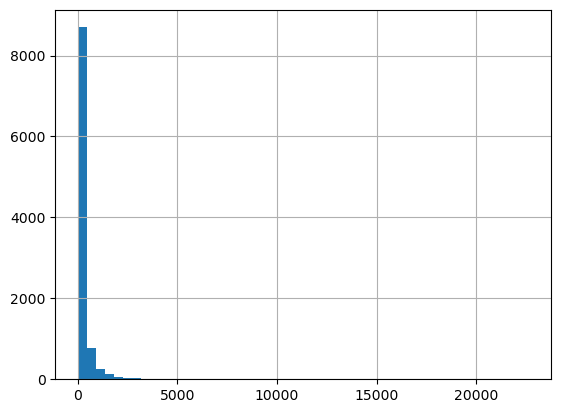

In [5]:
import matplotlib.pyplot as plt

df['List Price'].hist(bins=50)
plt.show()

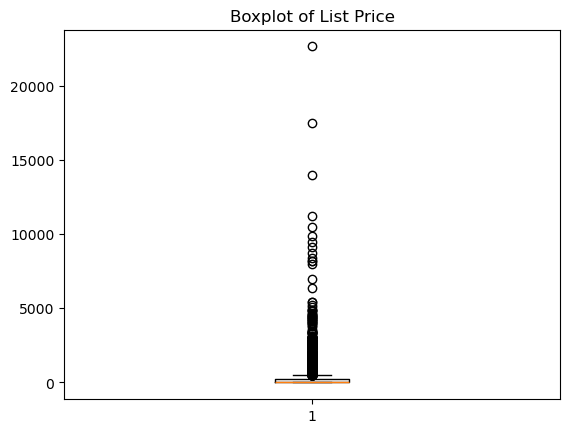

In [6]:
import matplotlib.pyplot as plt

plt.boxplot(df['List Price'])
plt.title('Boxplot of List Price')
plt.show()

In [10]:
df.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
9989    False
9990    False
9991    False
9992    False
9993    False
Length: 9994, dtype: bool

In [11]:
df.isnull().sum()

Order Id            0
Order Date          0
Ship Mode           1
Segment             0
Country             0
City                0
State               0
Postal Code         0
Region              0
Category            0
Sub Category        0
Product Id          0
cost price          0
List Price          0
Quantity            0
Discount Percent    0
dtype: int64

In [12]:
df["Ship Mode"]=df["Ship Mode"].fillna(df["Ship Mode"].mode([0]))

In [13]:
df.isnull().sum()

Order Id            0
Order Date          0
Ship Mode           1
Segment             0
Country             0
City                0
State               0
Postal Code         0
Region              0
Category            0
Sub Category        0
Product Id          0
cost price          0
List Price          0
Quantity            0
Discount Percent    0
dtype: int64

In [15]:
df.columns = df.columns.str.strip() # fixing spaces in column names


In [16]:
df["Ship Mode"]=df["Ship Mode"].fillna(df["Ship Mode"].mode()[0])

In [17]:
df.isnull().sum()

Order Id            0
Order Date          0
Ship Mode           0
Segment             0
Country             0
City                0
State               0
Postal Code         0
Region              0
Category            0
Sub Category        0
Product Id          0
cost price          0
List Price          0
Quantity            0
Discount Percent    0
dtype: int64

In [18]:
df.columns=df.columns.str.lower()

In [19]:
df.columns

Index(['order id', 'order date', 'ship mode', 'segment', 'country', 'city',
       'state', 'postal code', 'region', 'category', 'sub category',
       'product id', 'cost price', 'list price', 'quantity',
       'discount percent'],
      dtype='object')

In [20]:
df.head()

,order id,order date,ship mode,segment,country,city,state,postal code,region,category,sub category,product id,cost price,list price,quantity,discount percent
0,1,2023-03-01,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Bookcases,FUR-BO-10001798,240,260,2,2
1,2,2023-08-15,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Chairs,FUR-CH-10000454,600,730,3,3
2,3,2023-01-10,Second Class,Corporate,United States,Los Angeles,California,90036,West,Office Supplies,Labels,OFF-LA-10000240,10,10,2,5
3,4,2022-06-18,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,Tables,FUR-TA-10000577,780,960,5,2
4,5,2022-07-13,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Office Supplies,Storage,OFF-ST-10000760,20,20,2,5


In [24]:
df.nunique()

order id            9994
order date           730
ship mode              6
segment                3
country                1
city                 531
state                 49
postal code          631
region                 4
category               3
sub category          17
product id          1862
cost price           280
list price           289
quantity              14
discount percent       4
dtype: int64

#Calculate total revenue per order:
Revenue = List Price × Quantity
Find total sales by Category.
Find total sales by Region.
Find top 10 cities with highest revenue.
Find average discount per category.
find the correlation between sales and profit.

In [28]:
#calculate total revenue per order
df["total_revenue"] = df["quantity"] * df["list price"]
print(df["total_revenue"])


0        520
1       2190
2         20
3       4800
4         40
        ... 
9989      90
9990     180
9991     520
9992     120
9993     480
Name: total_revenue, Length: 9994, dtype: int64


In [30]:
#TOTAL REVENUE
df["total_revenue"].sum()

np.int64(11485170)

In [31]:
#avg revenue
df["total_revenue"].mean()

np.float64(1149.2065239143485)

In [33]:
#top 5 highest revenues
print(df.sort_values("total_revenue",ascending=False).head(5))


      order id  order date       ship mode      segment        country  \
2697      2698  2023-10-13  Standard Class  Home Office  United States   
9039      9040  2023-02-25  Standard Class     Consumer  United States   
6826      6827  2022-08-14  Standard Class    Corporate  United States   
165        166  2022-10-16  Standard Class     Consumer  United States   
4277      4278  2023-01-03  Standard Class    Corporate  United States   

              city       state  postal code   region         category  \
2697  Jacksonville     Florida        32216    South       Technology   
9039       Detroit    Michigan        48205  Central  Office Supplies   
6826     Lafayette     Indiana        47905  Central       Technology   
165    San Antonio       Texas        78207  Central       Technology   
4277      Lakewood  New Jersey         8701     East       Technology   

     sub category       product id  cost price  list price  quantity  \
2697     Machines  TEC-MA-10002412       181

In [34]:
#total revenue by category
print(df.groupby("category")["total_revenue"].sum())

category
Furniture          3857390
Office Supplies    3547450
Technology         4080330
Name: total_revenue, dtype: int64


In [36]:
#top products by revenue 
print(df.groupby("product id")["total_revenue"].sum().sort_values(ascending=False).head(10))

product id
TEC-CO-10004722    253400
OFF-BI-10000545    171510
TEC-MA-10002412    135840
FUR-CH-10002024    124470
TEC-PH-10001459    118090
TEC-CO-10001449    111480
OFF-BI-10003527    100620
TEC-MA-10000822     93330
FUR-BO-10002213     87270
TEC-MA-10001047     84500
Name: total_revenue, dtype: int64


In [38]:
#total profit by category
df["total_profit"] = (df["list price"] - df["cost price"]) * df["quantity"]
print(df.groupby("category")["total_profit"].sum())

category
Furniture          479430
Office Supplies    441200
Technology         525140
Name: total_profit, dtype: int64


In [40]:
print(df["category"].value_counts())
print(df["region"].value_counts())
print(df["segment"].value_counts())

category
Office Supplies    6026
Furniture          2121
Technology         1847
Name: count, dtype: int64
region
West       3203
East       2848
Central    2323
South      1620
Name: count, dtype: int64
segment
Consumer       5191
Corporate      3020
Home Office    1783
Name: count, dtype: int64


In [43]:
print(df.groupby("region")["total_profit"].sum())

region
Central    323270
East       416260
South      273910
West       432330
Name: total_profit, dtype: int64


In [64]:
#Which category contributes the highest percentage of total revenue?
(df.groupby("category")["total_revenue"].sum() / df["total_revenue"].sum()) * 100

category
Furniture          33.585833
Office Supplies    30.887222
Technology         35.526945
Name: total_revenue, dtype: float64

In [65]:
#❓ Which city generates the most revenue?
df.groupby("city")["total_revenue"].sum().sort_values(ascending=False).head(10)

city
New York City    1262920
Los Angeles       873070
Seattle           597310
Philadelphia      567510
San Francisco     541510
Houston           306200
Detroit           270350
San Diego         260390
Jacksonville      241800
Springfield       234780
Name: total_revenue, dtype: int64

In [66]:
#❓ Which segment is most profitable?
df.groupby("segment")["total_profit"].sum().sort_values(ascending=False)


segment
Consumer       723560
Corporate      451660
Home Office    270550
Name: total_profit, dtype: int64

In [67]:
#❓ Average order value by segment
df.groupby("segment")["total_revenue"].mean()

segment
Consumer       1120.485456
Corporate      1164.231788
Home Office    1207.375210
Name: total_revenue, dtype: float64

In [68]:
#❓ Which shipping mode generates highest revenue?
df.groupby("ship mode")["total_revenue"].sum().sort_values(ascending=False)

ship mode
Standard Class    6876550
Second Class      2376960
First Class       1624230
Same Day           587640
Not Available       19440
unknown               350
Name: total_revenue, dtype: int64

In [69]:
#Does faster shipping correlate with higher revenue?
df.groupby("ship mode")["total_revenue"].mean()

ship mode
First Class       1056.066320
Not Available     4860.000000
Same Day          1082.209945
Second Class      1222.087404
Standard Class    1153.203086
unknown            350.000000
Name: total_revenue, dtype: float64

<Axes: xlabel='discount percent'>

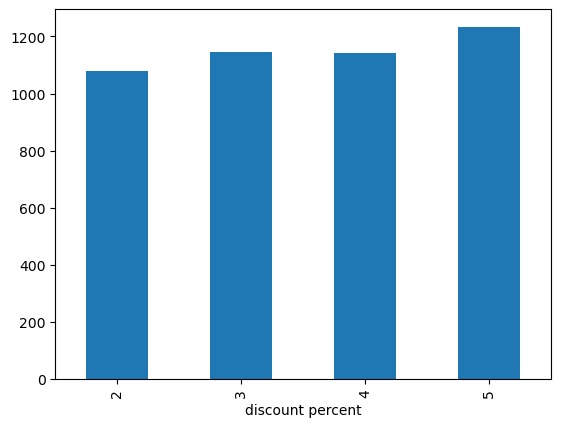

In [72]:
#❓ Does higher discount increase or decrease revenue?
df.groupby("discount percent")["total_revenue"].mean().plot(kind="bar")

In [73]:
df[["discount percent","total_revenue"]].corr()

,discount percent,total_revenue
discount percent,1.000000,0.013103
total_revenue,0.013103,1.000000


In [74]:
#❓ Which region is most profitable?
df.groupby("region")["total_profit"].sum().sort_values(ascending=False)

region
West       432330
East       416260
Central    323270
South      273910
Name: total_profit, dtype: int64

In [76]:
#Which products have high sales but low quantity?
df.groupby("product id")[["total_revenue","quantity"]].sum().sort_values("total_revenue",ascending=False).head(10)

,total_revenue,quantity
product id,,
TEC-CO-10004722,253400,20
OFF-BI-10000545,171510,48
TEC-MA-10002412,135840,6
FUR-CH-10002024,124470,39
TEC-PH-10001459,118090,39
TEC-CO-10001449,111480,38
OFF-BI-10003527,100620,31
TEC-MA-10000822,93330,18
FUR-BO-10002213,87270,42


<Axes: xlabel='order date'>

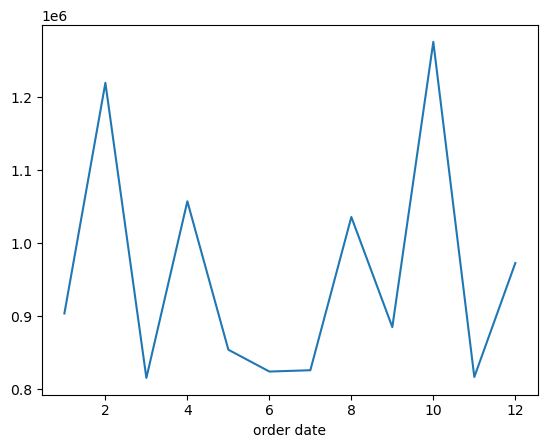

In [78]:
#❓ Monthly revenue trend
df["order date"] = pd.to_datetime(df["order date"])
df.groupby(df["order date"].dt.month)["total_revenue"].sum().plot(kind='line')

<Axes: xlabel='order date'>

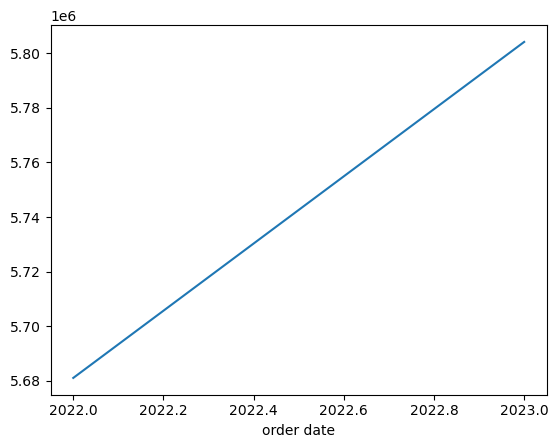

In [79]:
#yearly performance
df.groupby(df["order date"].dt.year)["total_revenue"].sum().plot(kind='line')

In [86]:
#Find top 20% products generating 80% revenue
product_revenue = df.groupby("product id")["total_revenue"].sum().sort_values(ascending=False)
cumulative_revenue = product_revenue.cumsum()
cumulative_revenue_percentage = cumulative_revenue / product_revenue.sum()*100
top_20_percent_threshold = product_revenue.sum()*0.2
top_products = product_revenue[cumulative_revenue_percentage <= 80]
print(top_products)
print(top_20_percent_threshold)

product id
TEC-CO-10004722    253400
OFF-BI-10000545    171510
TEC-MA-10002412    135840
FUR-CH-10002024    124470
TEC-PH-10001459    118090
                    ...  
OFF-PA-10003228      7210
TEC-PH-10003601      7200
OFF-ST-10000036      7180
TEC-AC-10002473      7080
OFF-BI-10003718      7080
Name: total_revenue, Length: 382, dtype: int64
2297034.0


In [87]:
# Which categories contain these top products?
df[df["product id"].isin(product_revenue.head(10).index)]["category"].value_counts()

category
Technology         26
Office Supplies    19
Furniture          18
Name: count, dtype: int64

In [ ]:
product_summary = df.groupby("product id").agg(
    total_revenue=("total_revenue", "sum"),
    quantity=("quantity", "sum")
).reset_index()

premium_products = product_summary.sort_values("total_revenue", ascending=False)

# filter: high revenue but low quantity
premium_products = premium_products[premium_products["quantity"] < premium_products["quantity"].median()]

print(premium_products.head(10))

In [ ]:
import pandas as pd

# 1. Total revenue per product
product_revenue = df.groupby("product id")["total_revenue"].sum()

# 2. Sort descending
product_revenue = product_revenue.sort_values(ascending=False)

# 3. Total revenue of all products
total_revenue = product_revenue.sum()

# 4. Cumulative revenue
cumulative_revenue = product_revenue.cumsum()

# 5. Cumulative percentage
cumulative_percent = (cumulative_revenue / total_revenue) * 100

# 6. Combine into one table
pareto_df = pd.DataFrame({
    "Revenue": product_revenue,
    "Cumulative Revenue": cumulative_revenue,
    "Cumulative %": cumulative_percent
})

# 7. Top 20% products (Pareto rule)
top_20_products = product_revenue.head(int(len(product_revenue) * 0.2))

print("Pareto Table (Top rows):")
print(pareto_df.head(10))

print("\n🔥 Top 20% Products:")
print(top_20_products)